In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv('../data/Bank_Churn.csv')

In [3]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='str')

In [5]:
df.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
#usuwamy kolumny niepotrzebne do analizy i modelu

df = df.drop(columns=['CustomerId', 'Surname'])

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


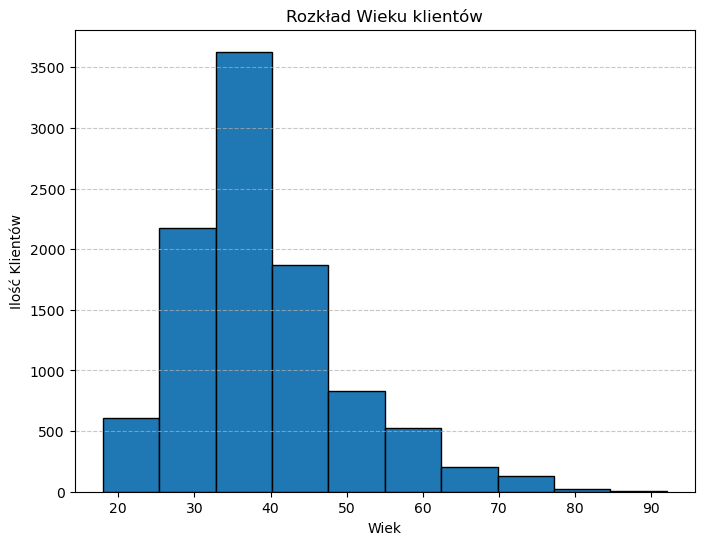

In [ ]:
# Wykres przedstawiający rozkład wieku klientów

plt.figure(figsize=(8,6))
ax = df['Age'].plot(
    kind='hist', 
    edgecolor = 'black', )

plt.xlabel('Wiek')
plt.ylabel('Ilość Klientów')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Rozkład Wieku klientów')
plt.show()


1. Kto najczęściej odchodzi? 

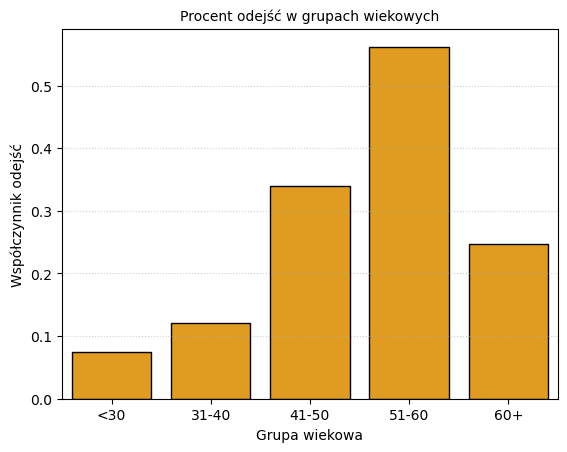

In [9]:
# Wykres pokazujący grupy wiekowe w których najwięcej klientów odchodzi 
bins = [0, 30, 40, 50, 60, 100]
labels = ['<30', '31-40', '41-50', '51-60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
sns.barplot(
    data=df, 
    x='Age_Group', 
    y='Exited', 
    color='orange', 
    edgecolor='black', 
    errorbar=None)


plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.title('Procent odejść w grupach wiekowych', fontsize=10)
plt.xlabel('Grupa wiekowa')
plt.ylabel('Współczynnik odejść')

plt.show()

Największe ryzyko odejścia występuje w grupie 41-60 lat. Jest to grupa zamożna, której utrzymanie powinno być priorytetem.

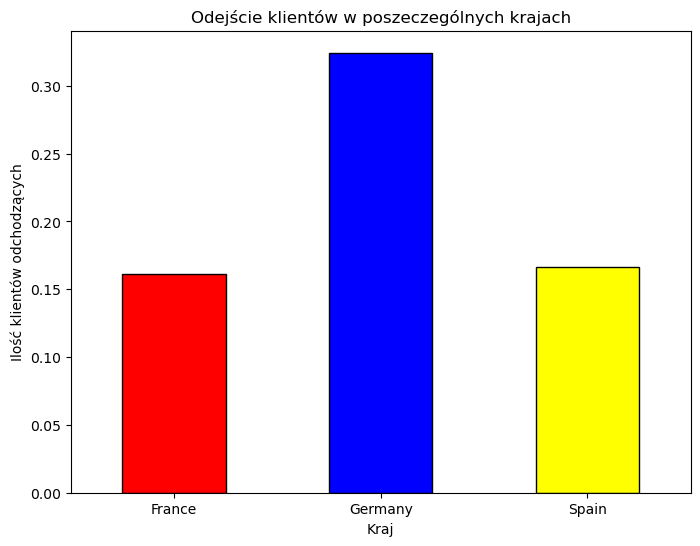

In [10]:
#wykres przedstawiający procentowy udział klientów odchodzących w każdym państwie, obliczamy średnią 
# bo suma byłaby niemiarodajna.


plt.figure(figsize=(8,6))
ax = df.groupby(by = 'Geography')['Exited'].mean().plot(
    kind='bar', 
    edgecolor = 'black', 
    color=['red', 'blue', 'yellow'])

plt.xlabel('Kraj')
plt.ylabel('Ilość klientów odchodzących')
plt.title('Odejście klientów w poszeczególnych krajach')
plt.xticks(rotation=0)
plt.show()

Rynek niemiecki jest najbardziej krytyczny . Mimo że Francja ma więcej klientów, to w Niemczech tracimy ich najszybciej.

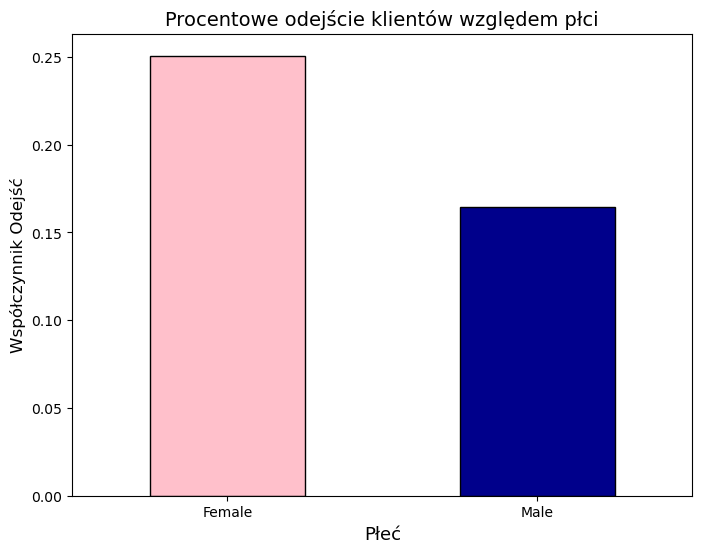

In [11]:
# wykres przedstawia ilość odejść względem płci


plt.figure(figsize=(8,6))
ax = df.groupby(by = 'Gender')['Exited'].mean().plot(
    kind='bar', 
    edgecolor = 'black', 
    color=['pink', 'darkblue'])

plt.xlabel('Płeć', fontsize=13)
plt.ylabel('Współczynnik Odejść', fontsize=12)
plt.title('Procentowe odejście klientów względem płci', fontsize=14)
plt.xticks(rotation=0)
plt.show()

Analiza wykazała, że płeć ma wpływ na lojalność klientów. Kobiety odchodzą z banku statystycznie częściej niż mężczyźni

2. Relacja z Bankiem

In [12]:
# sprawdzamy liczebność poszczególnych grup do wykresu poniżej

df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_22208\1394903565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


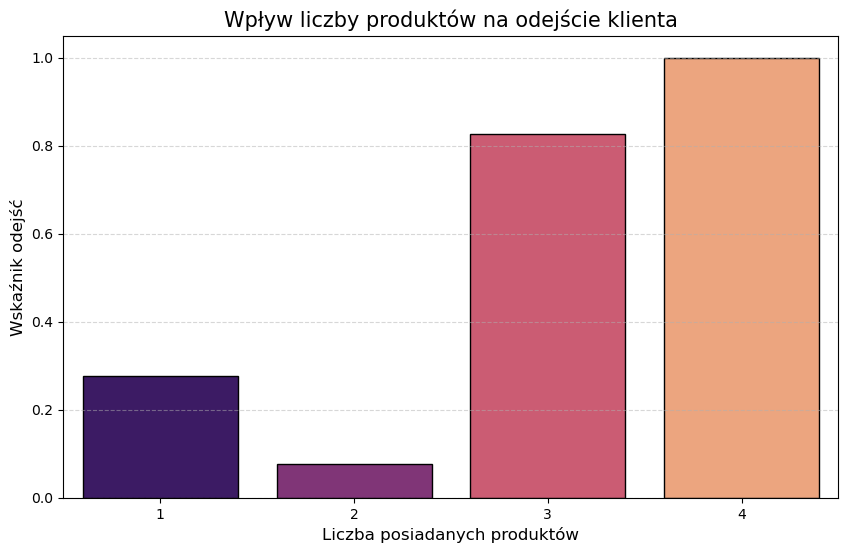

In [13]:
# Sprawdzamy czy większa ilość produktów wpływa na odejście klienta 


plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=df, 
    x='NumOfProducts', 
    y='Exited', 
    palette='magma', 
    errorbar=None, 
    edgecolor='black')

plt.title('Wpływ liczby produktów na odejście klienta', fontsize=15)
plt.xlabel('Liczba posiadanych produktów', fontsize=12)
plt.ylabel('Wskaźnik odejść', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

Jak można zauważyć na powyższym wykresie mniejsza liczba produktów bardziej sprzyja lojalności klieta, 
natomiast wskaźnik drastycznie rośnie powyżej 2 produktów, grupy te nie są liczne względem pozostałych ale wyniki mogą niepokojące i warte uwagi.

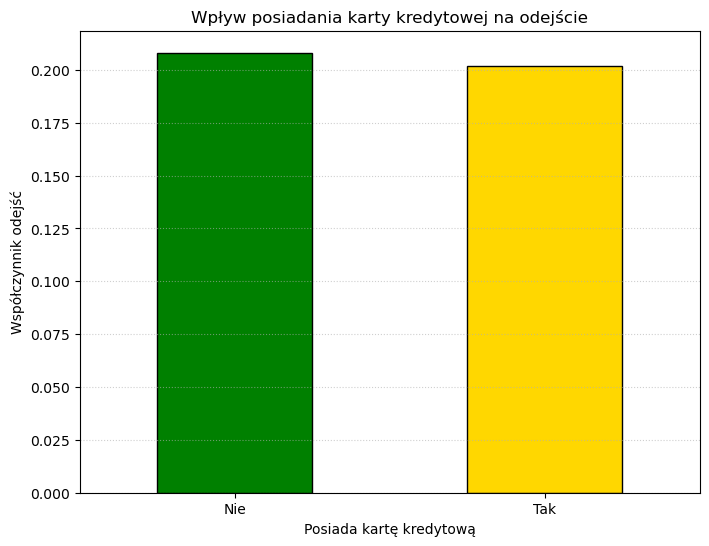

In [14]:
# Czy posiadanie karty wpływa na lojalność

plt.figure(figsize=(8,6))
ax = df.groupby(by = 'HasCrCard')['Exited'].mean().plot(
    kind='bar', 
    edgecolor = 'black', 
    color=['green', 'gold'])

plt.title('Wpływ posiadania karty kredytowej na odejście', fontsize=12)
plt.xlabel('Posiada kartę kredytową')
plt.ylabel('Współczynnik odejść')
plt.xticks([0, 1], ['Nie', 'Tak'], rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()


Karta kredytowa pomaga w małym stopniu zatrzymać klientów

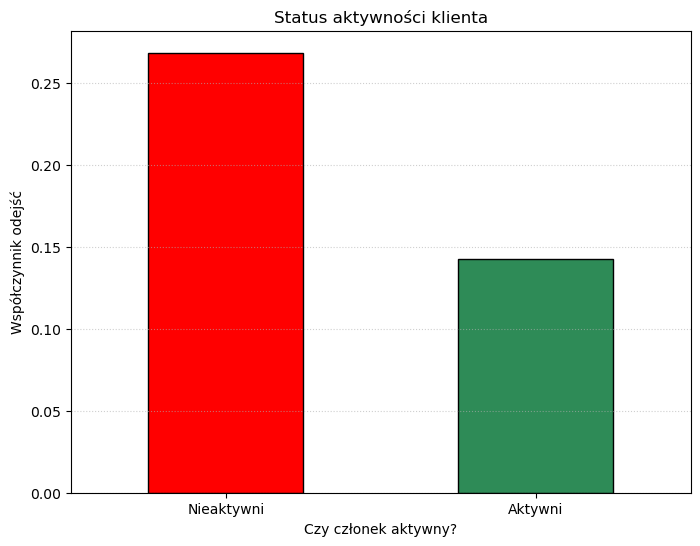

In [ ]:
# Czy status aktywności klienta ma wpływ na odejście 


plt.figure(figsize=(8,6))
ax = df.groupby(by='IsActiveMember')['Exited'].mean().plot(
    kind= 'bar', 
    edgecolor='black',
    color=['red', 'seagreen'])

plt.title('Status aktywności klienta', fontsize=12)
plt.xlabel('Czy członek aktywny?')
plt.ylabel('Współczynnik odejść')
plt.xticks([0, 1], ['Nieaktywni', 'Aktywni'], rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.6)

Analiza wykazała że członkowie nieaktywni odchodzą prawie dwa razy częściej w stosunku do osób aktywnych

3. Finanse, Czy pieniądze mają znaczenie?


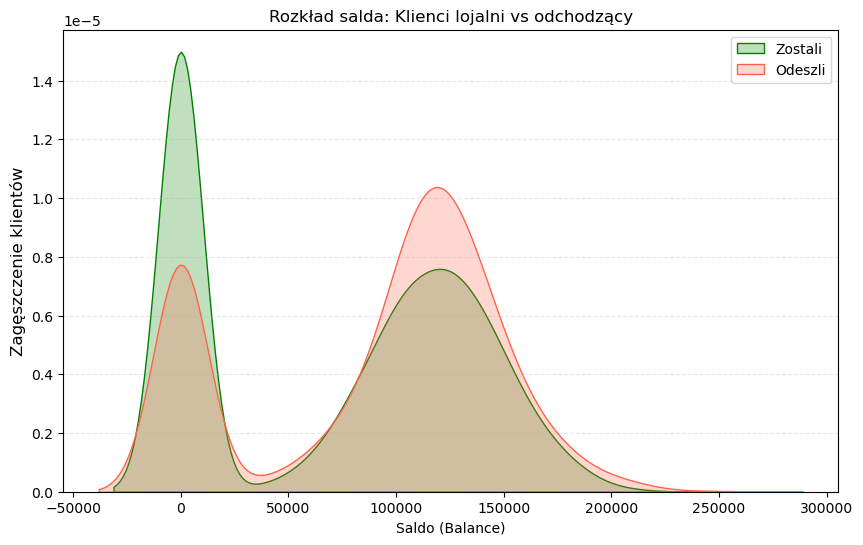

In [16]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Exited'] == 0]['Balance'], label='Zostali', fill=True, color="green")
sns.kdeplot(df[df['Exited'] == 1]['Balance'], label='Odeszli', fill=True, color="tomato")

plt.title('Rozkład salda: Klienci lojalni vs odchodzący')

plt.xlabel('Saldo (Balance)')
plt.ylabel('Zagęszczenie klientów', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Klienci z zerowym saldem rzadziej podejmują decyzję o odejściu niż klasa średnia. Może to wynikać z braku zaangażowania w relację z bankiem (konto nieużywane).

Krytyczny odpływ kapitału: Najwyższy wskaźnik odejść obserwujemy u klientów z saldem w przedziale 100,000 – 150,000 USD, na co trzeba zwrócić uwage aby powstrzymać odpływ najbardziej dochodowej grupy.

In [19]:
df.groupby('Exited')['EstimatedSalary'].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

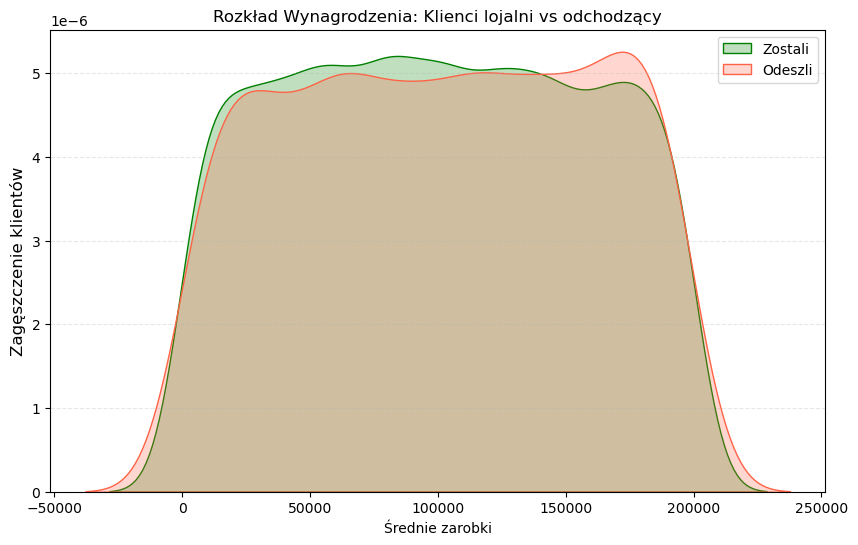

In [ ]:
# sprawdzamy czy zarobki mają wpływ na churn 

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Exited'] == 0]['EstimatedSalary'], label='Zostali', fill=True, color="green")
sns.kdeplot(df[df['Exited'] == 1]['EstimatedSalary'], label='Odeszli', fill=True, color="tomato")

plt.title('Rozkład Wynagrodzenia: Klienci lojalni vs odchodzący')

plt.xlabel('Średnie zarobki')
plt.ylabel('Zagęszczenie klientów', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Wykres  potwierdza, że szacowane wynagrodzenie nie jest czynnikiem różnicującym klientów pod kątem lojalności. Rozkład zarobków w obu grupach (Zostali vs Odeszli) jest niemal identyczny. Oznacza to, że skłonność do odejścia jest niezależna od poziomu zarobków klienta.